<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/deep_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Deep web (3pt)

Design a deep (narrow is enough, but have at least 11 layers) network. Test it first without BatchNorm, residual or dense links, or additional training layers. Finally, test at least two of these approaches so that you have at least 3 different models (ie, different placements of these elements).

Note: If you want to test residual or dense connections, design the network in such a way that there is a place to put them.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-13 15:40:46--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-13 15:40:46 (17.1 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-13 15:40:46--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:04<00:00, 40.5MB/s]


torch.Size([1, 3, 32, 32])


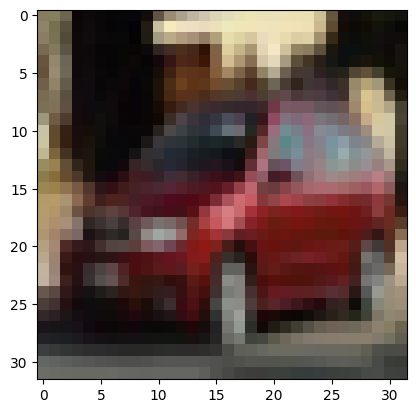

tensor([1])
car
torch.Size([1, 3, 32, 32])


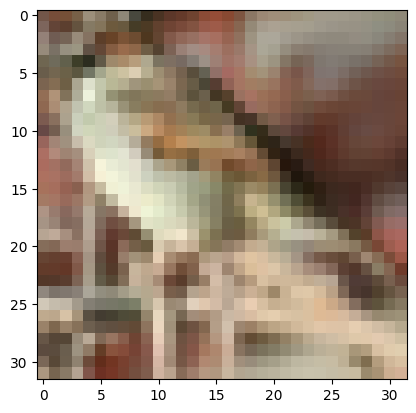

tensor([2])
bird
torch.Size([1, 3, 32, 32])


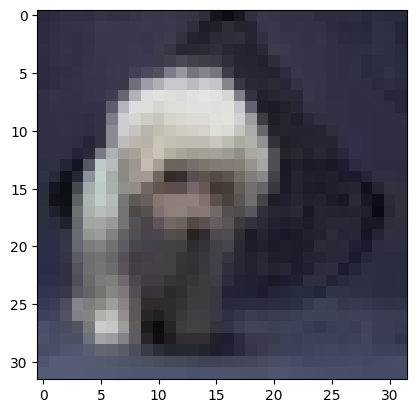

tensor([5])
dog
torch.Size([1, 3, 32, 32])


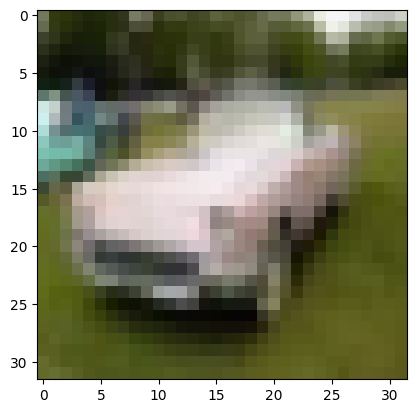

tensor([1])
car
torch.Size([1, 3, 32, 32])


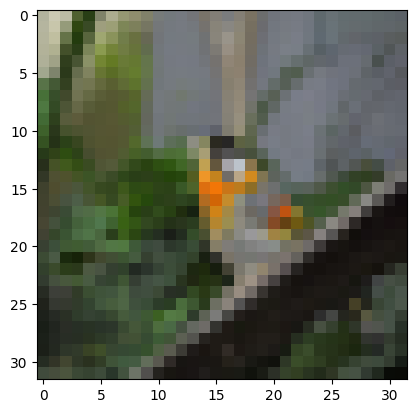

tensor([2])
bird
torch.Size([1, 3, 32, 32])


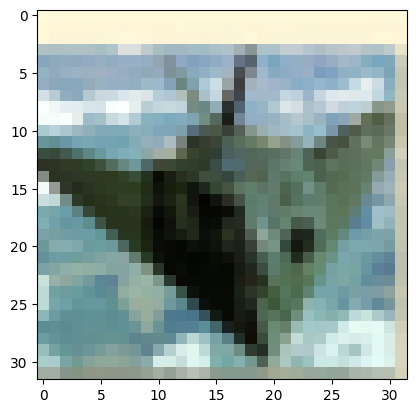

tensor([0])
plane
torch.Size([1, 3, 32, 32])


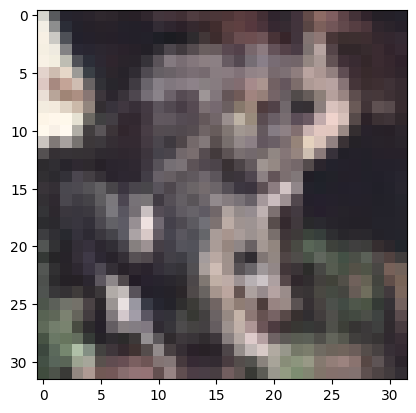

tensor([6])
frog
torch.Size([1, 3, 32, 32])


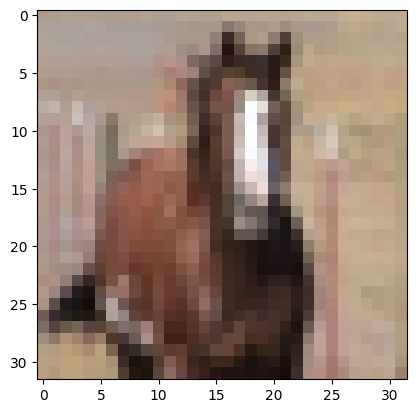

tensor([7])
horse
torch.Size([1, 3, 32, 32])


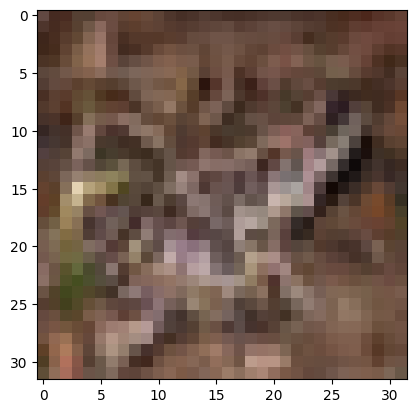

tensor([6])
frog
torch.Size([1, 3, 32, 32])


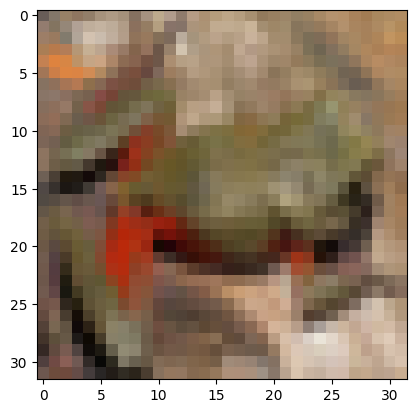

tensor([6])
frog
torch.Size([1, 3, 32, 32])


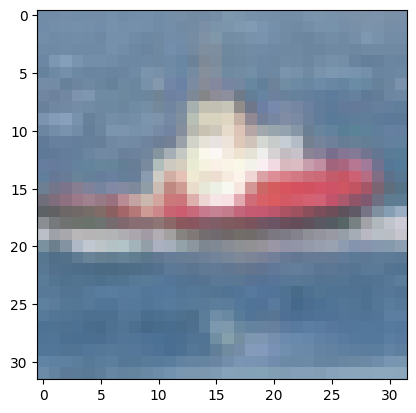

tensor([8])
ship


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [8]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, BatchNorm2d

def build_model_deep(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64), ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_deep_bn(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64),
        ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference

def build_model_even_deeper(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 128), ReLU(),
        Linear(128, 64), ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


model, model_inference = build_model_deep()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1078, 0.0884, 0.0980, 0.0990, 0.1096, 0.1114, 0.0856, 0.1057, 0.0913,
         0.1031]], grad_fn=<SoftmaxBackward0>)
dog


In [9]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying augmentation setting: deep_net
Val loss at epoch 0: 1.7095860645269891
Val acc at epoch 0: 0.367
Val loss at epoch 4: 1.122108687640755
Val acc at epoch 4: 0.5968
Val loss at epoch 8: 0.8693812561642592
Val acc at epoch 8: 0.6978
Val loss at epoch 12: 0.8757011212740734
Val acc at epoch 12: 0.7032
Val loss at epoch 16: 0.9688690204149598
Val acc at epoch 16: 0.7256
Val loss at epoch 20: 1.0922405567898112
Val acc at epoch 20: 0.7312
Val loss at epoch 24: 1.2743391064321918
Val acc at epoch 24: 0.717
Val loss at epoch 28: 1.5232947421301701
Val acc at epoch 28: 0.6914
Val loss at epoch 32: 1.3561952964515442
Val acc at epoch 32: 0.7124
Val loss at epoch 36: 1.6272748674556707
Val acc at epoch 36: 0.7036


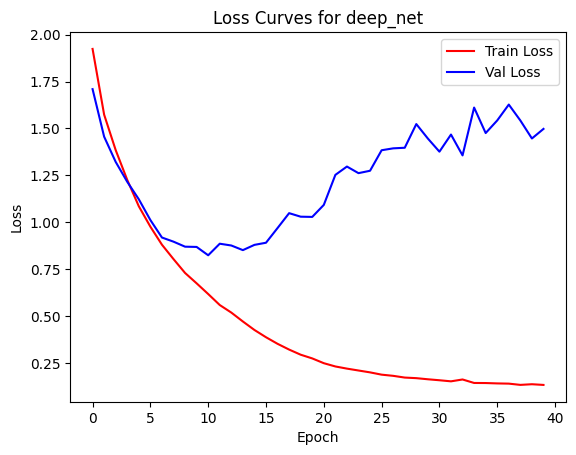

Trying augmentation setting: deep_net_bn
Val loss at epoch 0: 1.0764365826442743
Val acc at epoch 0: 0.611
Val loss at epoch 4: 0.5685623804475092
Val acc at epoch 4: 0.8032
Val loss at epoch 8: 0.5118113254096098
Val acc at epoch 8: 0.8296
Val loss at epoch 12: 0.6297887512334402
Val acc at epoch 12: 0.823
Val loss at epoch 16: 0.5936463860569486
Val acc at epoch 16: 0.8416
Val loss at epoch 20: 0.650791464622613
Val acc at epoch 20: 0.8394
Val loss at epoch 24: 0.7746504241968416
Val acc at epoch 24: 0.8344
Val loss at epoch 28: 0.8120489549840901
Val acc at epoch 28: 0.8298
Val loss at epoch 32: 0.7668003569457941
Val acc at epoch 32: 0.845
Val loss at epoch 36: 0.7364737416623505
Val acc at epoch 36: 0.8448


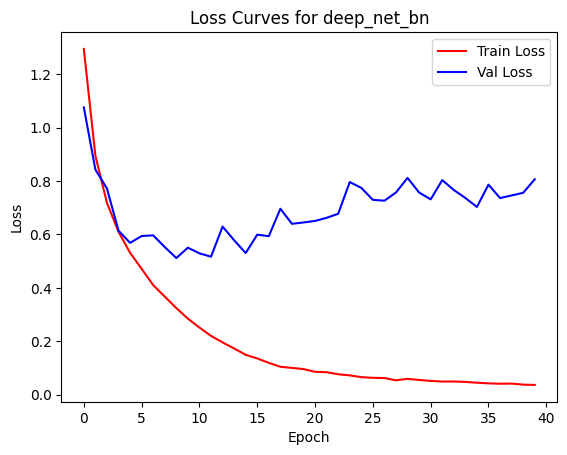

Trying augmentation setting: even_deeper_net
Val loss at epoch 0: 2.3029634906987475
Val acc at epoch 0: 0.1002
Val loss at epoch 4: 2.30311740279957
Val acc at epoch 4: 0.0942
Val loss at epoch 8: 2.302842039970835
Val acc at epoch 8: 0.1
Val loss at epoch 12: 2.302765692874884
Val acc at epoch 12: 0.0942
Val loss at epoch 16: 2.3028453231617143
Val acc at epoch 16: 0.0942
Val loss at epoch 20: 2.3029820478645857
Val acc at epoch 20: 0.0942
Val loss at epoch 24: 2.3028978071395
Val acc at epoch 24: 0.0942
Val loss at epoch 28: 2.3027374774787077
Val acc at epoch 28: 0.1002
Val loss at epoch 32: 2.302764886503766
Val acc at epoch 32: 0.0942
Val loss at epoch 36: 2.3028501234236796
Val acc at epoch 36: 0.0942


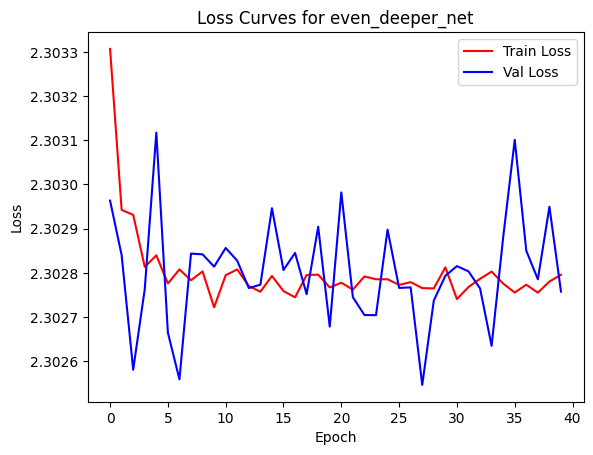

In [11]:
configs = [{'name': 'deep_net', 'build_model': build_model_deep},
           {'name': 'deep_net_bn', 'build_model': build_model_deep_bn},
           {'name': 'even_deeper_net', 'build_model': build_model_even_deeper}
           ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying augmentation setting: {config['name']}")

    build_model = config['build_model']
    model, model_inference = build_model()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        if e % 4 == 0:
          print(f"Val loss at epoch {e}: {val_loss}")
          print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [12]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'deep_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to deep_results.json


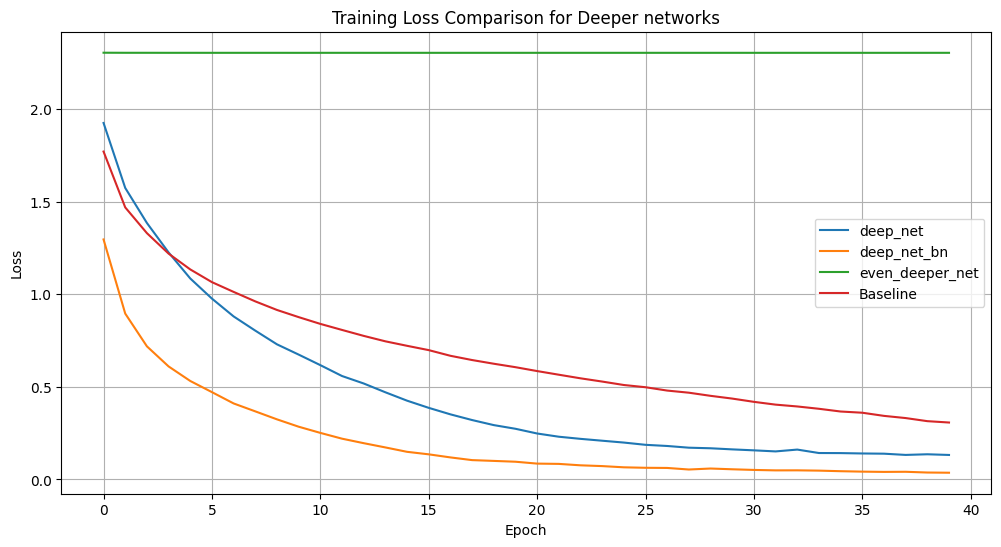

In [17]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline')

plt.title('Training Loss Comparison for Deeper networks')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

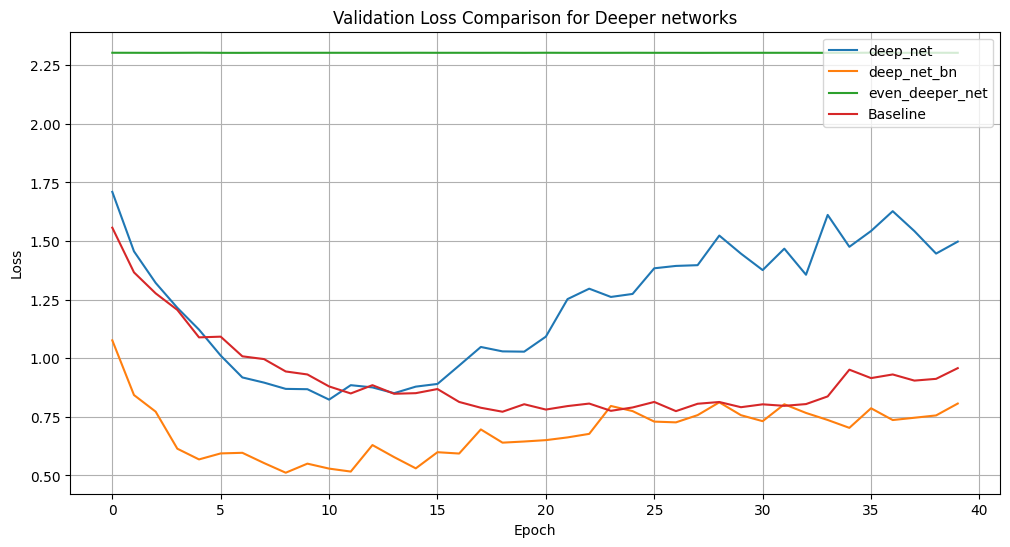

In [18]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline')

plt.title('Validation Loss Comparison for Deeper networks')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

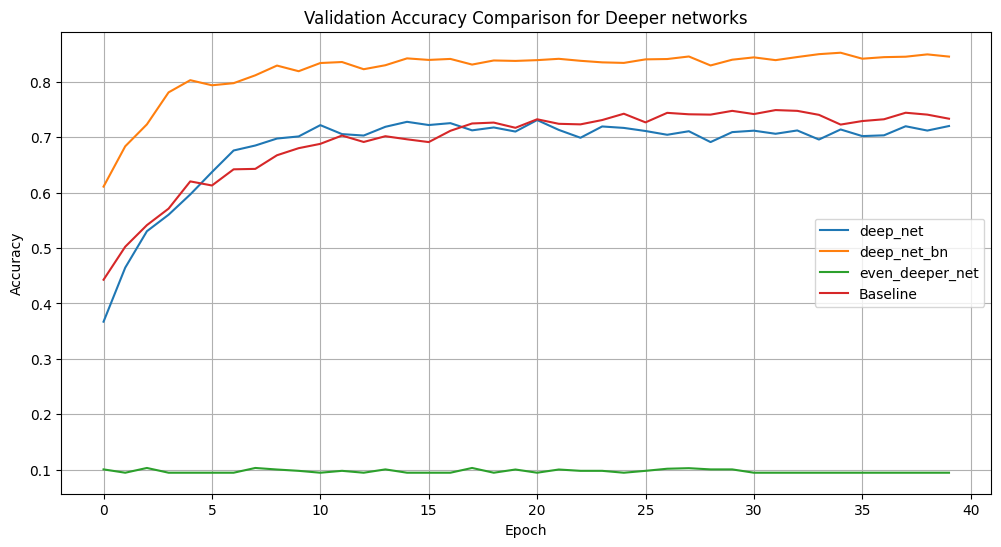

In [15]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline')

plt.title('Validation Accuracy Comparison for Deeper networks')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline,0.307193,0.957867,0.7336
deep_net,0.132089,1.497513,0.7204
deep_net_bn,0.036204,0.806845,0.8458
even_deeper_net,2.302796,2.302758,0.0942
